In [1]:

from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", DEVICE)


device = cpu


In [5]:
# DATA_ROOT = Path.cwd()

DATA_ROOT = Path.cwd() / "hazelnutData"

required_dirs = [
    DATA_ROOT / "train" / "good",
    DATA_ROOT / "test" / "good",
    DATA_ROOT / "ground_truth",
]
if not all(path.is_dir() for path in required_dirs):
    raise FileNotFoundError(
        "hazelnut フォルダ内で実行してください。\n"
        f"現在のフォルダ: {DATA_ROOT}\n"
        "必要なフォルダ: train/good, test/good, ground_truth"
    )

print("DATA_ROOT =", DATA_ROOT)



DATA_ROOT = /Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/hazelnutData


In [6]:
IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".bmp"}


In [7]:

def image_files(folder):
    return sorted(
        path for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )


TRAIN_GOOD_DIR = DATA_ROOT / "train" / "good"
TEST_DIR = DATA_ROOT / "test"
TEST_GOOD_DIR = TEST_DIR / "good"
GROUND_TRUTH_DIR = DATA_ROOT / "ground_truth"

In [8]:
train_good_paths = image_files(TRAIN_GOOD_DIR)
test_good_paths = image_files(TEST_GOOD_DIR)
anomaly_dirs = sorted(
    folder for folder in TEST_DIR.iterdir()
    if folder.is_dir() and folder.name != "good"
)
test_anomaly_paths = [
    path for folder in anomaly_dirs for path in image_files(folder)
]

print(f"train/good : {len(train_good_paths):3d} 枚")
print(f"test/good  : {len(test_good_paths):3d} 枚")
print(f"test/anom  : {len(test_anomaly_paths):3d} 枚")
print("異常の種類 :", [folder.name for folder in anomaly_dirs])
for folder in anomaly_dirs:
    print(f"  {folder.name:>5s}: {len(image_files(folder)):2d} 枚")

if not train_good_paths or not test_good_paths or not test_anomaly_paths:
    raise RuntimeError("必要な学習画像または評価画像が見つかりません。")



train/good : 391 枚
test/good  :  40 枚
test/anom  :  70 枚
異常の種類 : ['crack', 'cut', 'hole', 'print']
  crack: 18 枚
    cut: 17 枚
   hole: 18 枚
  print: 17 枚


In [9]:
print(train_good_paths)

[PosixPath('/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/hazelnutData/train/good/000.png'), PosixPath('/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/hazelnutData/train/good/001.png'), PosixPath('/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/hazelnutData/train/good/002.png'), PosixPath('/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/hazelnutData/train/good/003.png'), PosixPath('/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/hazelnutData/train/good/004.png'), PosixPath('/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/hazelnutData/train/good/005.png'), PosixPath('/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/hazelnutData/train/good/006.png'), PosixPath('/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture

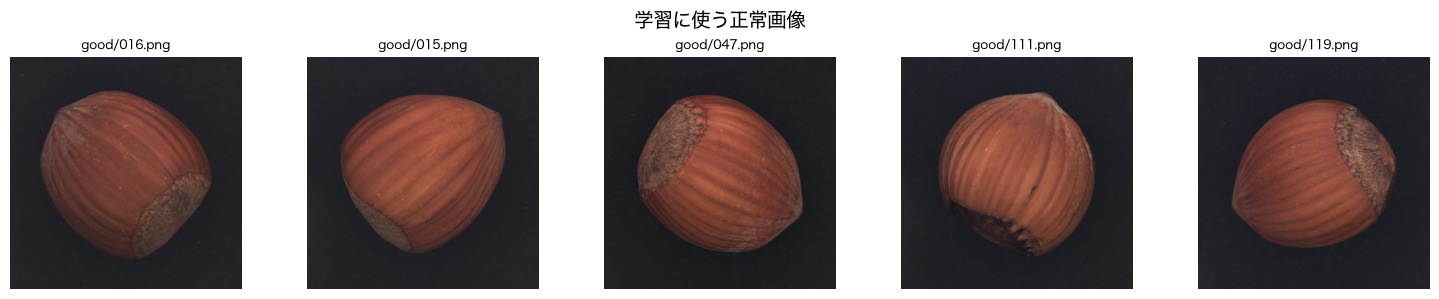

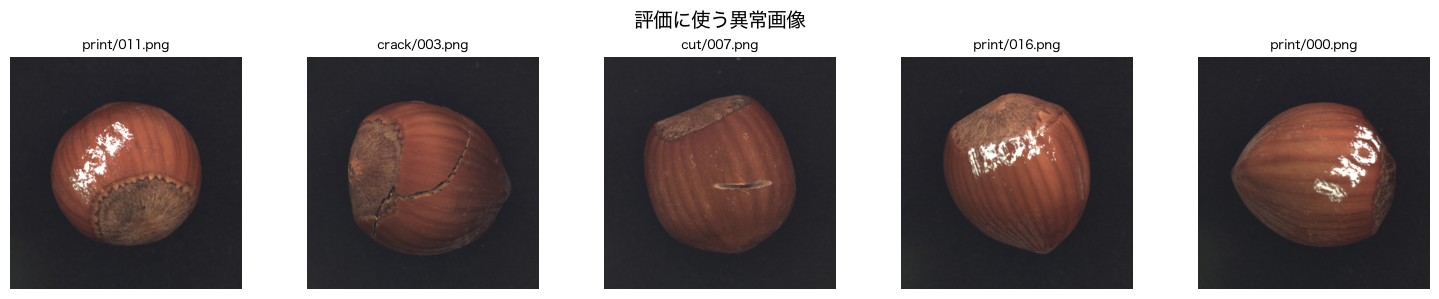

In [20]:
# import random
# import numpy as np
# import matplotlib.pyplot as plt
# from PIL import Image

# 日本語の文字化け対策（macOS）
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False


def show_images(paths, title, n=5):
    n = min(n, len(paths))

    if n == 0:
        print(f"{title}: 表示できる画像がありません")
        return

    selected = random.sample(paths, n)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    axes = np.atleast_1d(axes)

    for ax, path in zip(axes, selected):
        ax.imshow(Image.open(path).convert("RGB"))
        ax.set_title(
            f"{path.parent.name}/{path.name}",
            fontsize=9
        )
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


show_images(train_good_paths, "学習に使う正常画像")
show_images(test_anomaly_paths, "評価に使う異常画像")

In [22]:
IMG_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])


class HazelnutDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        path = self.image_paths[index]
        image = Image.open(path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, self.labels[index], str(path)


train_dataset = HazelnutDataset(
    train_good_paths, [0] * len(train_good_paths), transform
)
test_paths = test_good_paths + test_anomaly_paths
test_labels = [0] * len(test_good_paths) + [1] * len(test_anomaly_paths)
test_dataset = HazelnutDataset(test_paths, test_labels, transform)

# num_workers=0 は macOS・Windows・Jupyter でも扱いやすい設定。
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
train_score_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print("train batches =", len(train_loader))
print("test batches  =", len(test_loader))



train batches = 13
test batches  = 4


In [23]:
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


model = ConvAutoEncoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)


ConvAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


Epoch 01/50  loss = 0.064502
Epoch 05/50  loss = 0.004045
Epoch 10/50  loss = 0.000863
Epoch 15/50  loss = 0.000482
Epoch 20/50  loss = 0.000381
Epoch 25/50  loss = 0.000344
Epoch 30/50  loss = 0.000323
Epoch 35/50  loss = 0.000313
Epoch 40/50  loss = 0.000296
Epoch 45/50  loss = 0.000283
Epoch 50/50  loss = 0.000277


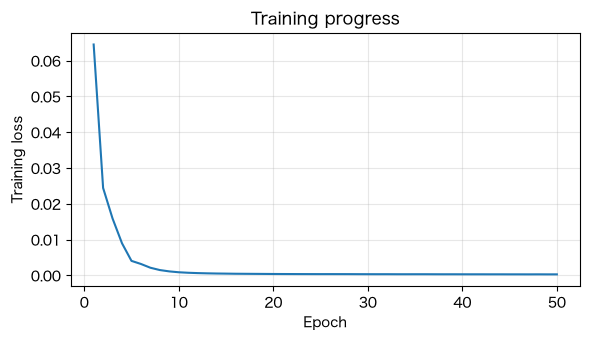

In [24]:
EPOCHS = 50
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, _, _ in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    loss_history.append(epoch_loss)
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:02d}/{EPOCHS}  loss = {epoch_loss:.6f}")


# %%
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, EPOCHS + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training progress")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



正常画像の例


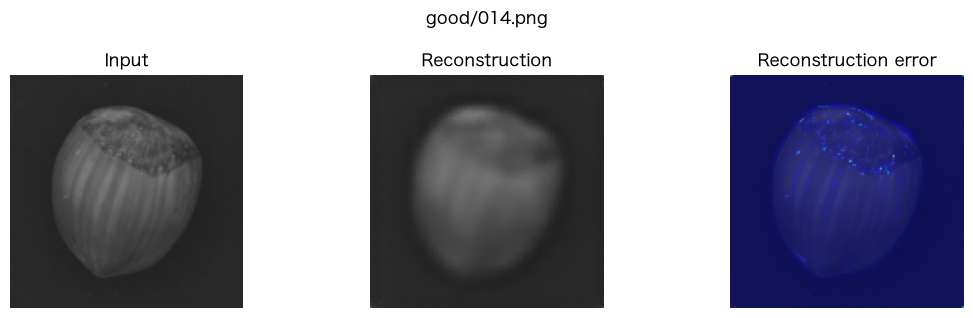

異常画像の例


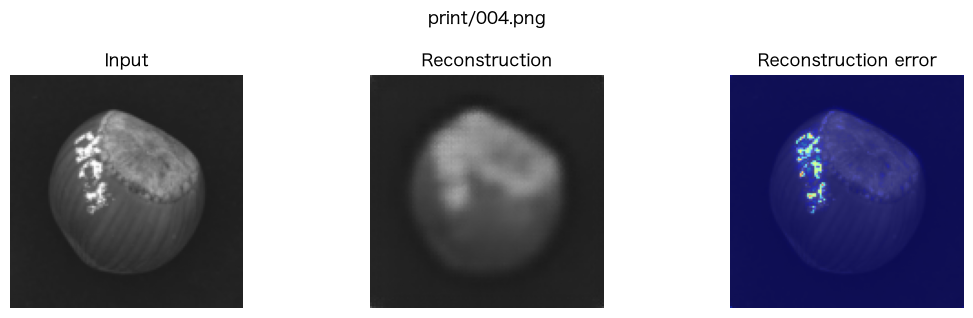

In [25]:
def reconstruct(image_path):
    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        y = model(x)

    input_image = x[0, 0].cpu().numpy()
    reconstructed = y[0, 0].cpu().numpy()
    error_map = (reconstructed - input_image) ** 2
    return input_image, reconstructed, error_map


def show_reconstruction(image_path):
    input_image, reconstructed, error_map = reconstruct(image_path)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

    axes[0].imshow(input_image, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input")
    axes[1].imshow(reconstructed, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Reconstruction")
    axes[2].imshow(input_image, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(error_map, cmap="jet", alpha=0.55)
    axes[2].set_title("Reconstruction error")

    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{image_path.parent.name}/{image_path.name}")
    plt.tight_layout()
    plt.show()


print("正常画像の例")
show_reconstruction(random.choice(test_good_paths))
print("異常画像の例")
show_reconstruction(random.choice(test_anomaly_paths))



In [26]:
TOP_RATIO = 0.05
BORDER = 8


def topk_reconstruction_error(images, outputs, top_ratio=0.05, border=8):
    error_map = (outputs - images).pow(2).mean(dim=1)

    height, width = error_map.shape[-2:]
    if border > 0 and 2 * border < height and 2 * border < width:
        error_map = error_map[:, border:-border, border:-border]

    flat_error = error_map.flatten(start_dim=1)
    k = max(1, int(flat_error.size(1) * top_ratio))
    return torch.topk(flat_error, k=k, dim=1).values.mean(dim=1)


def calculate_scores(loader):
    model.eval()
    all_scores, all_labels, all_paths = [], [], []

    with torch.no_grad():
        for images, labels, paths in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            scores = topk_reconstruction_error(
                images, outputs, TOP_RATIO, BORDER
            )
            all_scores.extend(scores.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(Path(path) for path in paths)

    return np.asarray(all_scores), np.asarray(all_labels), all_paths


train_scores, _, _ = calculate_scores(train_score_loader)
test_scores, y_true, evaluated_paths = calculate_scores(test_loader)

# 学習用正常画像の95%がこの値以下になるように、しきい値を決める。
threshold = np.percentile(train_scores, 95)
y_pred = (test_scores >= threshold).astype(int)

print(f"top ratio               = {TOP_RATIO:.2f}")
print(f"threshold               = {threshold:.6f}")
print(f"test normal mean score  = {test_scores[y_true == 0].mean():.6f}")
print(f"test anomaly mean score = {test_scores[y_true == 1].mean():.6f}")



top ratio               = 0.05
threshold               = 0.005999
test normal mean score  = 0.002937
test anomaly mean score = 0.013729


ROC-AUC           = 0.9232
Average Precision = 0.9596
Accuracy          = 0.7182

              precision    recall  f1-score   support

      normal      0.563     1.000     0.721        40
     anomaly      1.000     0.557     0.716        70

    accuracy                          0.718       110
   macro avg      0.782     0.779     0.718       110
weighted avg      0.841     0.718     0.717       110



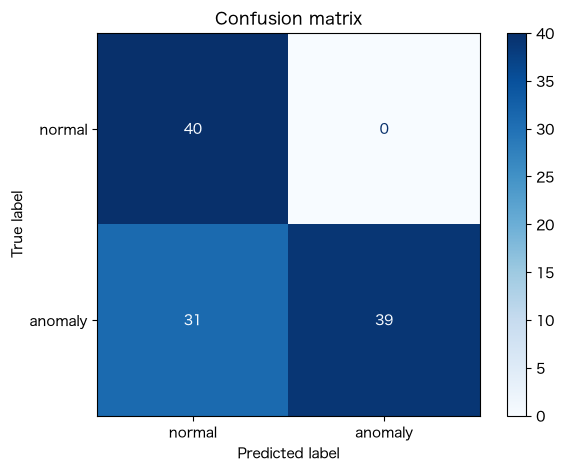

In [27]:
roc_auc = roc_auc_score(y_true, test_scores)
average_precision = average_precision_score(y_true, test_scores)
accuracy = (y_pred == y_true).mean()

print(f"ROC-AUC           = {roc_auc:.4f}")
print(f"Average Precision = {average_precision:.4f}")
print(f"Accuracy          = {accuracy:.4f}")
print()
print(classification_report(
    y_true,
    y_pred,
    target_names=["normal", "anomaly"],
    digits=3,
    zero_division=0,
))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["normal", "anomaly"],
).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()



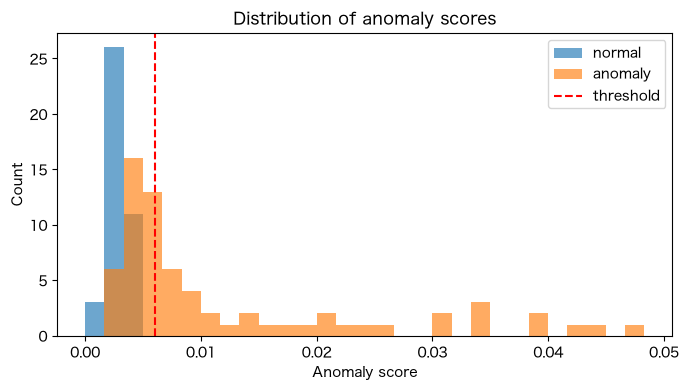

In [28]:
normal_scores = test_scores[y_true == 0]
anomaly_scores = test_scores[y_true == 1]
upper = np.percentile(np.r_[normal_scores, anomaly_scores], 99)
bins = np.linspace(0, upper, 30)

plt.figure(figsize=(7, 4))
plt.hist(normal_scores, bins=bins, alpha=0.65, label="normal")
plt.hist(anomaly_scores, bins=bins, alpha=0.65, label="anomaly")
plt.axvline(threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.title("Distribution of anomaly scores")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
evaluated_types = np.array([
    "good" if label == 0 else path.parent.name
    for label, path in zip(y_true, evaluated_paths)
])

print(f"{'type':>8s}  {'n':>3s}  {'mean score':>12s}  {'detected':>10s}")
for defect_type in ["good"] + [folder.name for folder in anomaly_dirs]:
    selected = evaluated_types == defect_type
    if not selected.any():
        continue
    print(
        f"{defect_type:>8s}  "
        f"{selected.sum():3d}  "
        f"{test_scores[selected].mean():12.6f}  "
        f"{y_pred[selected].mean():10.3f}"
    )


    type    n    mean score    detected
    good   40      0.002937       0.000
   crack   18      0.014738       0.611
     cut   17      0.004254       0.059
    hole   18      0.006641       0.556
   print   17      0.029639       1.000


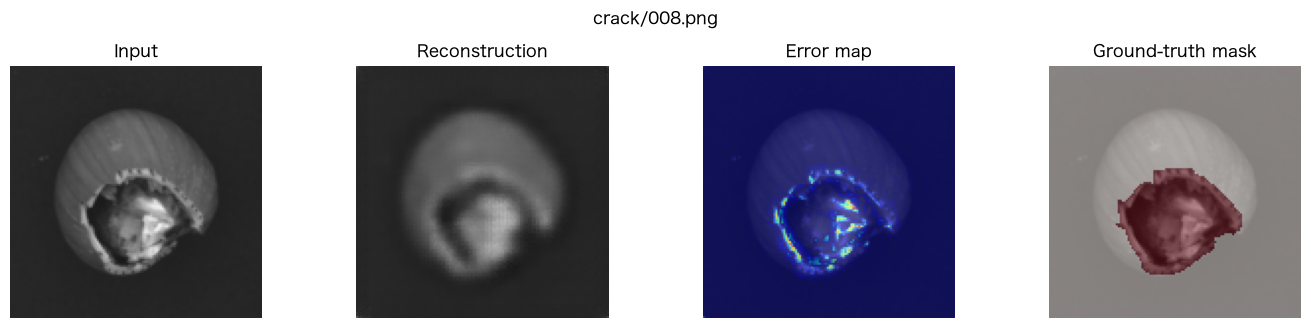

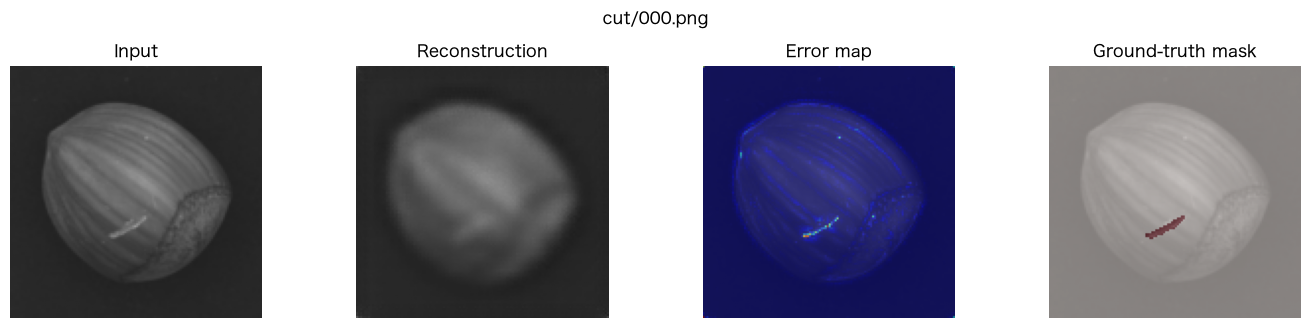

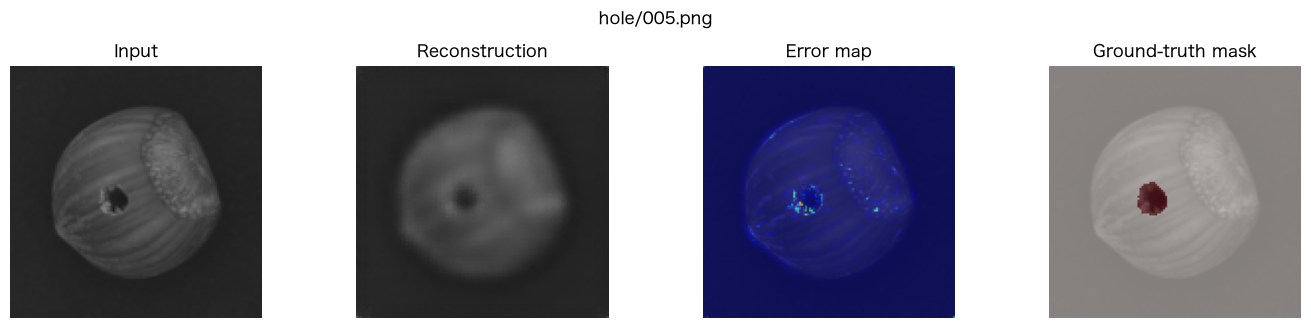

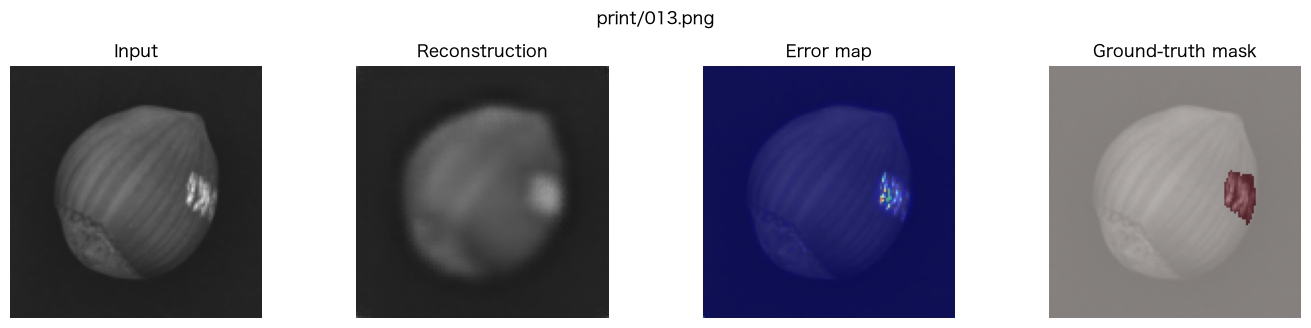

In [30]:
def mask_path_for(image_path):
    image_path = Path(image_path)
    return (
        GROUND_TRUTH_DIR
        / image_path.parent.name
        / f"{image_path.stem}_mask.png"
    )


def show_localization(image_path):
    image_path = Path(image_path)
    input_image, reconstructed, error_map = reconstruct(image_path)
    mask_path = mask_path_for(image_path)

    if not mask_path.exists():
        raise FileNotFoundError(f"正解マスクが見つかりません: {mask_path}")

    mask = Image.open(mask_path).convert("L").resize(
        (IMG_SIZE, IMG_SIZE), Image.Resampling.NEAREST
    )
    mask = np.asarray(mask) > 0

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.3))
    axes[0].imshow(input_image, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input")
    axes[1].imshow(reconstructed, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Reconstruction")
    axes[2].imshow(input_image, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(error_map, cmap="jet", alpha=0.55)
    axes[2].set_title("Error map")
    axes[3].imshow(input_image, cmap="gray", vmin=0, vmax=1)
    axes[3].imshow(mask, cmap="Reds", alpha=0.45)
    axes[3].set_title("Ground-truth mask")

    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{image_path.parent.name}/{image_path.name}")
    plt.tight_layout()
    plt.show()


# crack、cut、hole、print から1枚ずつ表示する。
for folder in anomaly_dirs:
    paths = image_files(folder)
    if paths:
        show_localization(random.choice(paths))



In [31]:
def calculate_pixel_auc(anomaly_paths):
    all_pixel_labels, all_pixel_scores = [], []

    for image_path in anomaly_paths:
        _, _, error_map = reconstruct(image_path)
        mask_path = mask_path_for(image_path)
        if not mask_path.exists():
            print("mask skipped:", mask_path)
            continue

        mask = Image.open(mask_path).convert("L").resize(
            (IMG_SIZE, IMG_SIZE), Image.Resampling.NEAREST
        )
        mask = (np.asarray(mask) > 0).astype(np.uint8)
        all_pixel_labels.append(mask.ravel())
        all_pixel_scores.append(error_map.ravel())

    if not all_pixel_labels:
        return np.nan

    return roc_auc_score(
        np.concatenate(all_pixel_labels),
        np.concatenate(all_pixel_scores),
    )


pixel_auc = calculate_pixel_auc(test_anomaly_paths)
print(f"Pixel-level ROC-AUC = {pixel_auc:.4f}")




Pixel-level ROC-AUC = 0.8866
